In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def grid(A):
    x1_grids = np.arange(-10,10+1)
    x2_grids = np.arange(-10,10+1)
    xx1,xx2 = np.meshgrid(x1_grids,x2_grids)
    #沿着axis = 2(深度)将网格堆叠为三维数组
        #在1D数组中axis = 0就是自己的轴,不存在行业列,横着写和2D数组的axis = 1的列方向无关
        #在2Daxis = 0和axis = 1中0表示行,1表示列
        #更高维度中axis=0永远指的是最外层依次向里 [[[[]]]] 最外层就是最外层axis = 0.每向里一层加1
        #数据怎么定义xyz或者zxy等都无所谓,关键是[]的嵌套,最外层就是axis = 0,每向里面就加一层
    #注意这里的向量是2D 是很多的x,y组成的
    #这里的广播规则与逐元素广播不同
    X_grid = np.stack([xx1,xx2],axis = 2) 
    #A使用的是行向量数据,使用右乘A.T 结果等价于列向量数据左乘A
    A_X_grid = X_grid @ A.T 

    return A_X_grid

In [5]:
def circle(A):
    theta_array = np.linspace(0,2*np.pi,721)
    #极坐标到直角坐标系
    #默认半径是1,直接输出对应横纵坐标
    x1_array = np.cos(theta_array)
    x2_array = np.sin(theta_array)
    unit_circle = np.column_stack([x1_array,x2_array])

    A_unit_circle = unit_circle @ A.T#

    return A_unit_circle

In [9]:
def unit_square(A):
    unit_square = np.array([[0,0],
                            [1,0],
                            [1,1],
                            [0,1]])

    A_unit_square = unit_square@A.T#
    return A_unit_square

In [11]:
def vectors(A):
    e1 = np.array([[1],
                   [0]])
    Ae1 = A@e1

    e2 = np.array([[0],
                   [1]])
    Ae2 = A@e2

    all_1 = e1 + e2
    A_all_1 = A @ all_1

    return Ae1,Ae2,A_all_1

In [47]:
def visualize(A):
    fig,ax = plt.subplots()

    #调用自定义函数创建数据
    A_X_grid = grid(A)
    A_unit_square = unit_square(A)
    A_unit_circle = circle(A)
    Ae1,Ae2,A_all_1 = vectors(A)

    for i in range(A_X_grid.shape[0]): 
        plt.plot(A_X_grid[i,:,0], #3D深度数组,0表示x坐标
                 A_X_grid[i,:,1], #1表示y坐标
                 'k-',linewidth = 0.5) #k-表示黑色实现
    for j in range(A_X_grid.shape[1]):
        plt.plot(A_X_grid[:,j,0],
                 A_X_grid[:,j,1],
                 'k-',linewidth = 0.5)

    plt.quiver(0,0,Ae1[0],Ae1[1],angles = 'xy',scale_units = 'xy',scale = 1,color = [1,0,0],zorder = 1e5)
    plt.quiver(0,0,Ae2[0],Ae2[1],angles = 'xy',scale_units = 'xy',scale = 1,color = [0,1,0],zorder = 1e5)
    plt.quiver(0,0,A_all_1[0],A_all_1[1],angles = 'xy',scale_units = 'xy',scale = 1,color = [0,0,0],zorder = 1e5)
    
    plt.plot(A_unit_circle[:,0],A_unit_circle[:,1],c = 'k',ls = '--')

    #取出数组后是1D数组,函数输入就是左边1D数组x右边1D数组y,对应组合画填充
    plt.fill(A_unit_square[:,0],A_unit_square[:,1],c = '#FFFFCC',ls = '--',zorder = 1)

    #装饰
    plt.axvline(x = 0,color = 'k',zorder = 0)
    plt.axhline(y = 0,color = 'k',zorder = 0)
    ax.tick_params(axis = 'both',which = 'both',length = 0,labelbottom = False,labelleft = False) #
    ax.set_aspect(1)
    lim = 3;ax.set_xlim([-lim,lim]);ax.set_ylim([-lim,lim])
    plt.xticks(np.arange(-lim,lim));plt.yticks(np.arange(-lim,lim))
    ax.grid(linestyle = '--',linewidth = 0.15,color = [0.8,0.8,0.8])

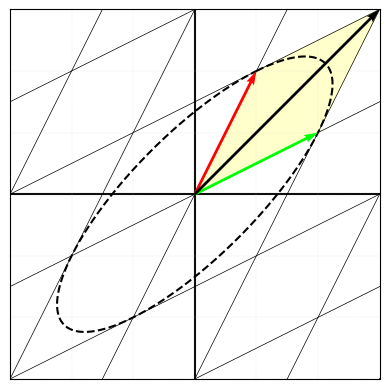

In [49]:
A = np.array([[1,2],
              [2,1]])
visualize(A)

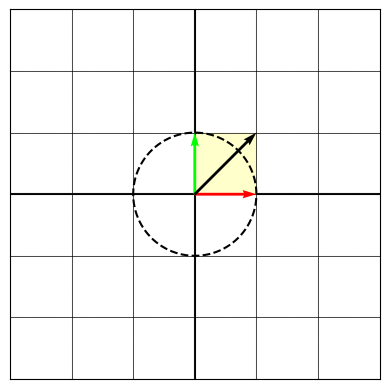

In [51]:
A = np.array([[1,0],
              [0,1]])
visualize(A)

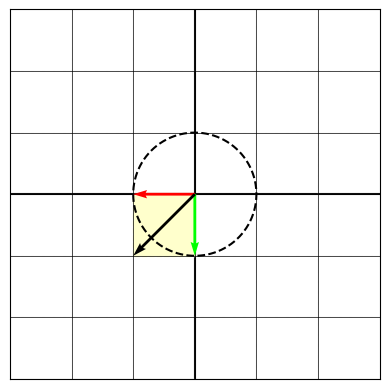

In [53]:
A = np.array([[-1,0],
              [0,-1]])
visualize(A)

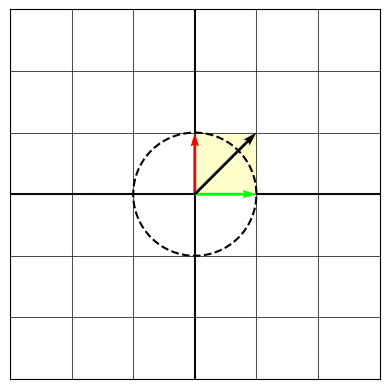

In [55]:
A = np.array([[0,1],
              [1,0]])
visualize(A)

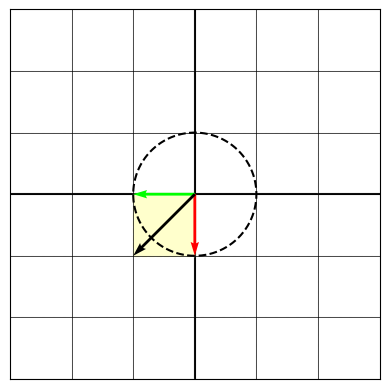

In [57]:
A = np.array([[0,-1],
              [-1,0]])
visualize(A)

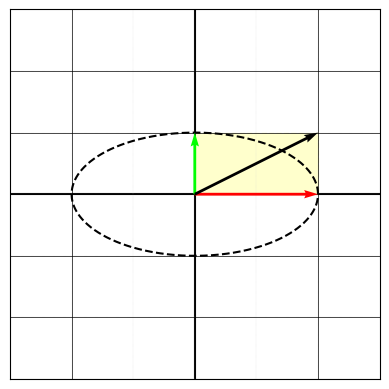

In [59]:
A = np.array([[2,0],
              [0,1]])
visualize(A)

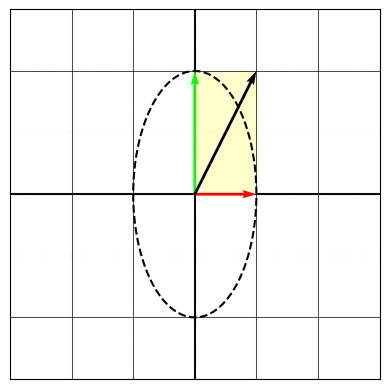

In [61]:
A = np.array([[1,0],
              [0,2]])
visualize(A)

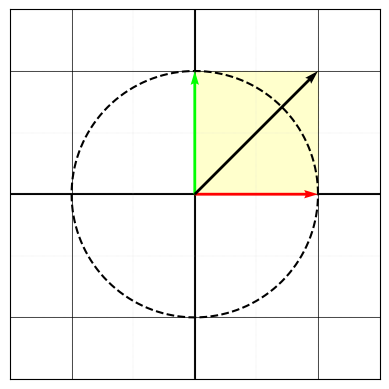

In [67]:
A = np.array([[2,0],
              [0,2]])
visualize(A)

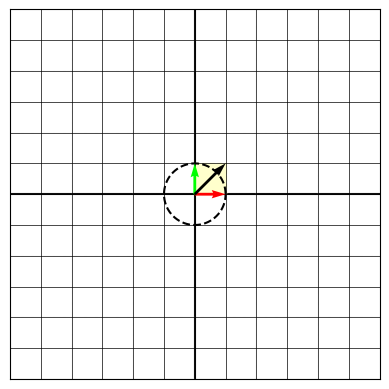

In [69]:
A = np.array([[1/2,0],
              [0,1/2]])
visualize(A)

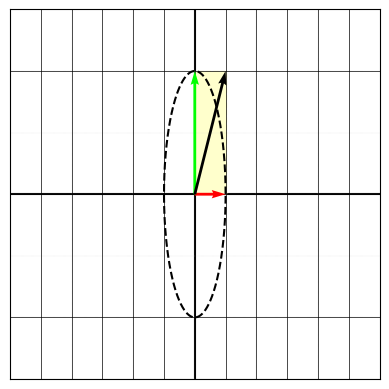

In [71]:
A = np.array([[1/2,0],
              [0,2]])
visualize(A)

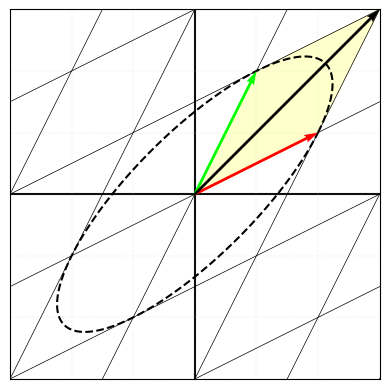

In [73]:
A = np.array([[2,1],
              [1,2]])
visualize(A)

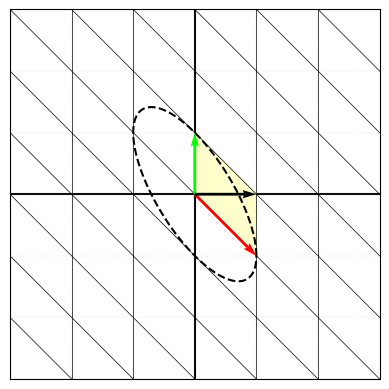

In [75]:
A = np.array([[1,0],
              [-1,1]])
visualize(A)

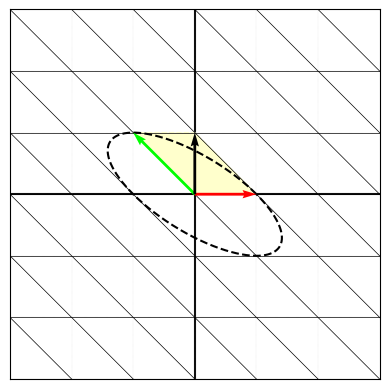

In [77]:
A = np.array([[1,-1],
              [0,1]])
visualize(A)

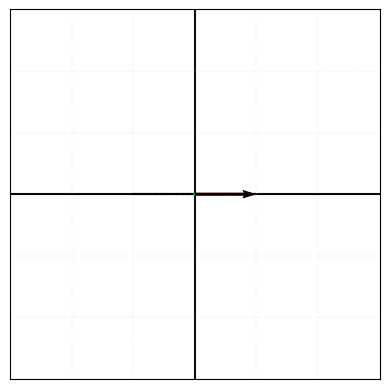

In [79]:
A = np.array([[1,0],
              [0,0]])
visualize(A)

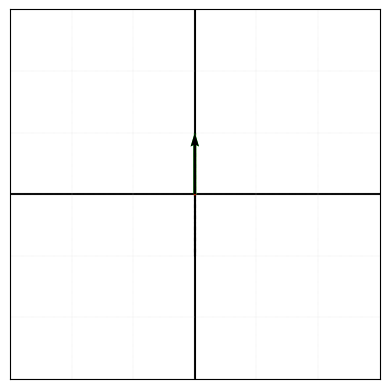

In [81]:
A = np.array([[0,0],
              [0,1]])
visualize(A)

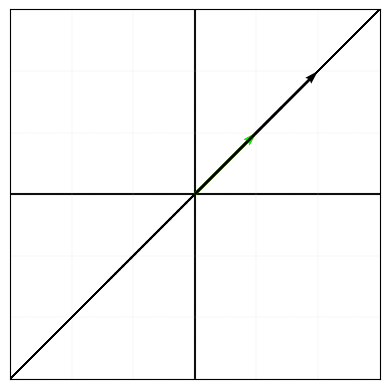

In [83]:
A = np.array([[1,1],
              [1,1]])
visualize(A)

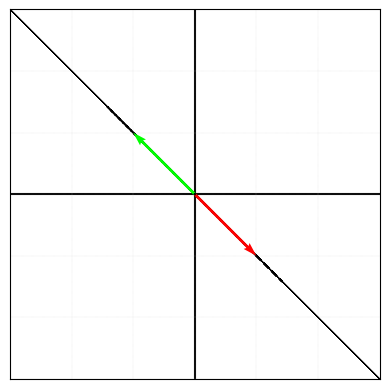

In [87]:
A = np.array([[1,-1],
              [-1,1]])
visualize(A)

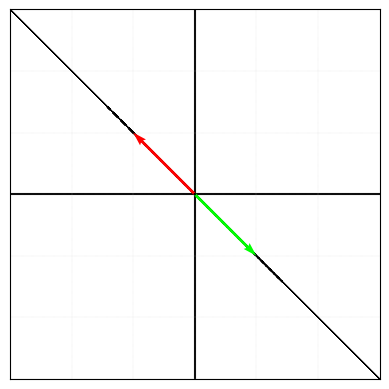

In [91]:
A = np.array([[-1,1],
              [1,-1]])
visualize(A)

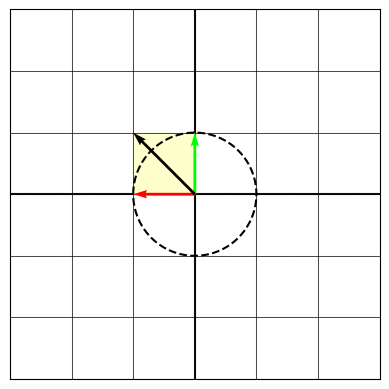

In [93]:
A = np.array([[-1,0],
              [0,1]])
visualize(A)

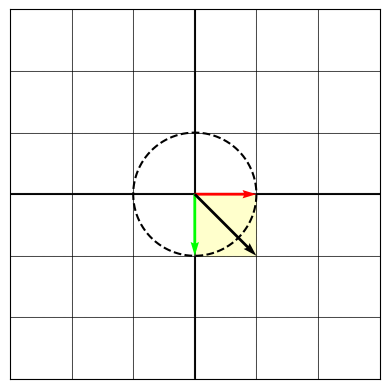

In [95]:
A = np.array([[1,0],
              [0,-1]])
visualize(A)